In [1]:
import pvlib
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import datetime 
import pytz
import pandas as pd
import numpy as np
import requests
import math

In [3]:
lat = 47.99
long = 139.53
time_zone = 'Asia/Vladivostok'
loc = pvlib.location.Location(lat, long, time_zone)
start_time = datetime.datetime(2023, 1, 1, 0)
end_time = datetime.datetime(2023, 12, 31, 23)
model_freq = '1h'

date_array = pd.date_range(start = start_time,
                           end = end_time,
                           freq = model_freq,
                           tz = time_zone) 


In [6]:
PV_Modules_source = pvlib.pvsystem.retrieve_sam(name = None, path = 'CEC_Modules.csv')
PV_Modules = PV_Modules_source.transpose()
PV_Modules = PV_Modules.rename_axis('Name').reset_index()
Module = PV_Modules.iloc['AU_Optronics_PM096B00_327']
Module

C:\Users\Serg\anaconda3\Lib\site-packages\pvlib\pvsystem.py:2135: UserWarning: Original names contain 505 duplicate(s).
  warnings.warn('Original names contain %d duplicate(s).' % n_duplicates)
C:\Users\Serg\anaconda3\Lib\site-packages\pvlib\pvsystem.py:2139: UserWarning: Normalized names contain 505 duplicate(s).
  warnings.warn(


TypeError: Cannot index by location index with a non-integer key

In [10]:
PV_Modules_chosen1 = pd.DataFrame(columns = PV_Modules.columns)

PV_P_min_1 = 320
PV_type_1 = 'Mono-c-Si'
PV_bifacial_1 = 0
PV_V_oc_ref_1 = 60
Square_max_1 = 2
eff_min_1 = 0.2

ind = 0
for i in range(len(PV_Modules)):
    if math.isnan(PV_Modules['Length'].iloc[i]) == False: # Проверка на наличие данных о габаритах
        if PV_Modules['STC'].iloc[i] >= PV_P_min_1: # по мощности
            if PV_Modules['Technology'].iloc[i] == PV_type_1: # по типу СЭ, может быть:
                                                                 # CdTe
                                                                 # CIGS
                                                                 # Mono-c-Si
                                                                 # Multi-c-Si
                                                                 # Thin Film
                if PV_Modules['Bifacial'].iloc[i] == PV_bifacial_1: # односторонний (0) или двусторонний (1)
                    if PV_Modules['V_oc_ref'].iloc[i] > PV_V_oc_ref_1: # по величине напряжения холостого хода
                        if PV_Modules['A_c'].iloc[i] < Square_max_1: # по площади
                            PV_Modules_chosen1.loc[ind] = PV_Modules.iloc[i]
                            ind += 1



In [13]:
Module = PV_Modules_chosen1.iloc[3]
Module

Name            AU_Optronics_PM096B00_327
Manufacturer                 AU Optronics
Technology                      Mono-c-Si
Bifacial                                0
STC                               327.106
PTC                                 299.3
A_c                                 1.631
Length                              1.559
Width                               1.046
N_s                                    96
I_sc_ref                             6.46
V_oc_ref                             64.9
I_mp_ref                             5.98
V_mp_ref                             54.7
alpha_sc                         0.004005
beta_oc                         -0.198594
T_NOCT                               48.3
a_ref                             2.60588
I_L_ref                           6.46832
I_o_ref                               0.0
R_s                              0.364689
R_sh_ref                          283.267
Adjust                            10.0383
gamma_pmp                         

In [32]:
irrad = [100,300,500,700,900,1100,1300]
t_amb = 15


In [33]:
a = -3.56
b = -0.075
deltaT = 3
Cells_temperature_PVGIS = []
for i in range (100,1301,200):
    Cells_temperature_PVGIS.append(pvlib.temperature.sapm_cell(i, 
                            15, 
                            0, 
                            a, 
                            b, 
                            deltaT, 
                            irrad_ref=1000.0))
Cells_temperature_PVGIS 

[18.14388247141845,
 24.43164741425535,
 30.719412357092253,
 37.007177299929154,
 43.294942242766055,
 49.582707185602956,
 55.87047212843986]

In [41]:
DC_out = [0.0] * 7

for i in range (7):
    
    I_L, I_0, R_s, R_sh, nNsVth = pvlib.pvsystem.calcparams_desoto(effective_irradiance = irrad[i],
                                                                   temp_cell = Cells_temperature_PVGIS[i],
                                                                   alpha_sc = Module['alpha_sc'],
                                                                   a_ref = Module['a_ref'],
                                                                   I_L_ref = Module['I_L_ref'],
                                                                   I_o_ref = Module['I_o_ref'],
                                                                   R_sh_ref = Module['R_sh_ref'],
                                                                   R_s = Module['R_s'],
                                                                   EgRef = 1.121,
                                                                   dEgdT = -0.0002677,
                                                                   irrad_ref = 1000,
                                                                   temp_ref = 25)
                                                                   
                                                                   
    
    DC_out[i] = pvlib.pvsystem.singlediode(photocurrent = I_L,
                               saturation_current = I_0 , 
                               resistance_series = R_s, 
                               resistance_shunt = R_sh,
                               nNsVth = nNsVth,
                               method = 'newton')

power = [0] * 7
for i in range (7):
    power[i] = DC_out[i]['p_mp']



[31.32477871153881,
 95.63558899993662,
 157.969536348635,
 217.43045147915058,
 273.6627674248929,
 326.46418443160593,
 375.69959846678387]

C:\Users\Serg\AppData\Local\Temp\ipykernel_2876\4071078339.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  generate['Year'].iloc[i] = power[i] * 8760 / 1000


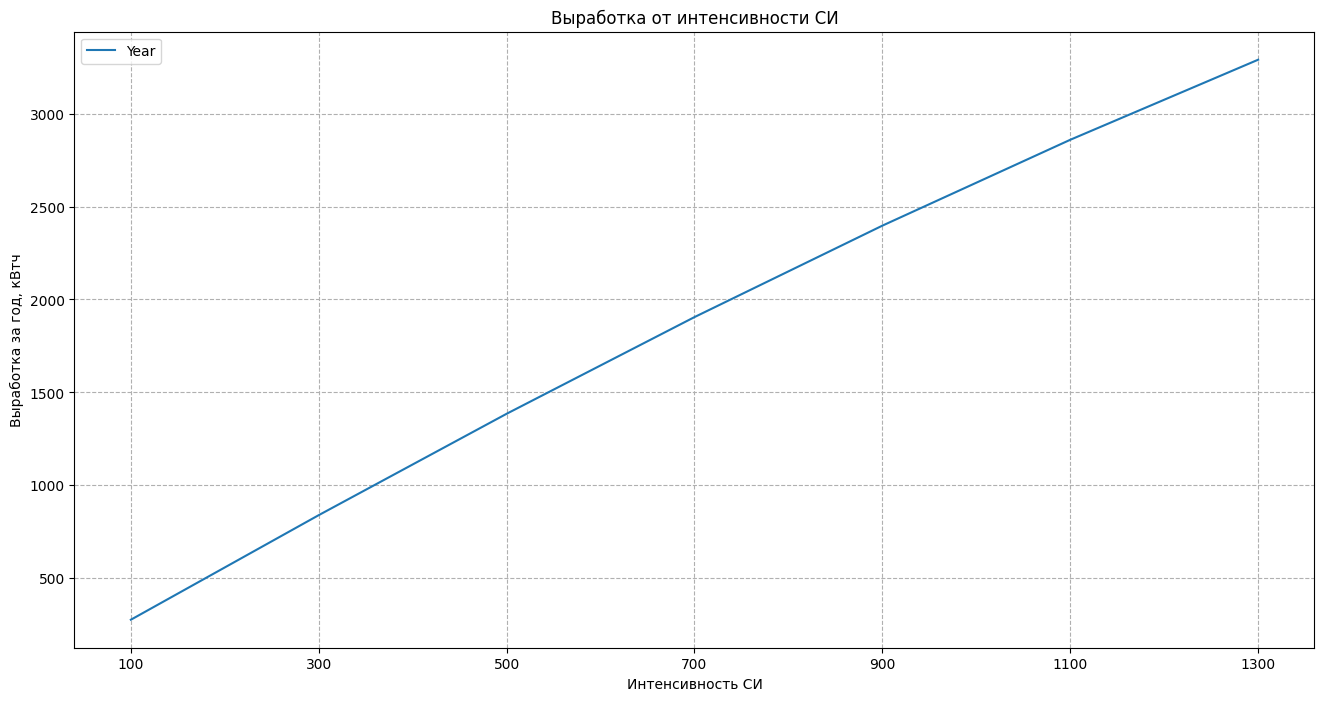

In [52]:
generate = pd.DataFrame(index = ['100','300','500','700','900','1100','1300'], columns=['Year'])
for i in range (7):
    generate['Year'].iloc[i] = power[i] * 8760 / 1000

generate.plot(figsize=(16,8), label='Year')
plt.legend()
plt.grid(linestyle='--')
plt.ylabel('Выработка за год, кВтч')
plt.xlabel('Интенсивность СИ')
plt.title('Выработка от интенсивности СИ')
plt.show()

In [51]:
generate

,Year
100,274.405062
300,837.76776
500,1383.813138
700,1904.690755
900,2397.285843
1100,2859.826256
1300,3291.128483
